# Classification Modeling With Lag Features

The image below shows the five levels of API values, which are related to health effects and actions to be taken. 

Ref : (https://www.doe.gov.my/2021/10/04/english-air-pollutant-index-api/)

![alt text here](https://www.doe.gov.my/wp-content/uploads/2022/03/API-Status-300x240-1.png)

## Labeling

In [1]:
import pandas as pd
# Load dataset
df = pd.read_csv('../data/interim/preprocessed_df2.csv')

In [2]:
def classify_api(api):
    if api <= 50:
        return 'Good'
    elif api <= 100:
        return 'Moderate'
    elif api <= 200:
        return 'Unhealthy'
    elif api <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['API_Category'] = df['API'].apply(classify_api)

In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['API_Category_Encoded'] = label_encoder.fit_transform(df['API_Category'])
categories = label_encoder.classes_  # To see the mapping of categories
print(categories)

['Good' 'Moderate' 'Unhealthy']


The output ['Good', 'Moderate', 'Unhealthy'] shows that the LabelEncoder only encountered these three categories in the dataset. The dataset does not have any API values greater than 200 or greater than 300, which would generate the categories 'Very Unhealthy' or 'Hazardous'

## Data Split

In [4]:
features = ['API_lag1', 
            'API_lag3', 
            'API_lag6',
            'PM10 1H (µg/m3)', 
            'PM2.5 1H (µg/m3)', 
            'SO2 1H (ppm)', 
            'NO2 1H (ppm)',
            'O3 1H (ppm)', 
            'CO 1H (ppm)', 
            'WIND DIRECTION 1H (°)',
            'WIND SPEED 1H (m/s)', 
            'RELATIVE HUMIDITY 1H (%)', 
            'Ambient Temperature 1H (°c)']

# Drop rows with missing values
df_cleaned = df.dropna()

# Verify if there are any missing values left
print("Number of missing values:", df_cleaned.isnull().sum().sum())

X = df_cleaned[features]
y = df_cleaned['API_Category_Encoded']

Number of missing values: 0


In [5]:
from sklearn.model_selection import train_test_split

# Train-Test Split
seed_value = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value)

# Confirm shapes of the datasets
print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (196352, 13) (196352,)
Test set: (49088, 13) (49088,)


## Set Up

In [6]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, matthews_corrcoef, make_scorer
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed
seed_value = 42

# Define save location
model_folder_path = "../models/classification/with_lag_values"
if not os.path.exists(model_folder_path):
    os.makedirs(model_folder_path)

report_folder_path = "../reports/classification/with_lag_values"
if not os.path.exists(report_folder_path):
    os.makedirs(report_folder_path)

In [7]:
def evaluate_classification_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro')
    recall_macro = recall_score(y_test, y_pred, average='macro')
    f1_macro = f1_score(y_test, y_pred, average='macro')

    precision_weighted = precision_score(y_test, y_pred, average='weighted')
    recall_weighted = recall_score(y_test, y_pred, average='weighted')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    mcc = matthews_corrcoef(y_test, y_pred)

    report = classification_report(y_test, y_pred, digits=4)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'mcc': mcc,
        'classification_report': report,
        'confusion_matrix': cm
    }


In [8]:
# Define MCC scorer
mcc_scorer = make_scorer(matthews_corrcoef)

# Grid search with MCC as the scoring metric
def grid_search_tuning(model, param_grid, X_train, y_train):
    grid_search = GridSearchCV(estimator=model, 
                               param_grid=param_grid, 
                               cv=5, scoring=mcc_scorer,  # Using MCC as the scoring metric
                               n_jobs=-1, error_score='raise')
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_


In [9]:
# Define parameter grids

param_grid_lr = [
    # Grid for 'liblinear' solver
    {
        'penalty': ['l1', 'l2'],  # 'None' is not supported by 'liblinear'
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear'],
        'max_iter': [100, 200, 500]
    },
    # Grid for 'saga' solver
    {
        'penalty': ['l1', 'l2', 'elasticnet'],  # 'elasticnet' is supported only by 'saga'
        'C': [0.01, 0.1, 1, 10],
        'solver': ['saga'],
        'max_iter': [100, 200, 500],
        'l1_ratio': [0.1, 0.5, 0.7, 1]  # Adding l1_ratio for elasticnet penalty
    }
]


param_grid_gnb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
}

param_grid_dt = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

In [10]:
# Define models
classification_lr = LogisticRegression(random_state=seed_value)
classification_gnb = GaussianNB()
classification_dt = DecisionTreeClassifier(random_state=seed_value)
classification_rf = RandomForestClassifier(random_state=seed_value)
classification_knn = KNeighborsClassifier()

In [11]:
# Save model function
def save_model(model, file_path: str):
    with open(file_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Model saved to {file_path}")

## Model Training

In [12]:
# Training and saving
print('Training Classification Models...')

Training Classification Models...


In [13]:
print('Logistic Regression model...')
classification_lr_model = grid_search_tuning(classification_lr, param_grid_lr, X_train, y_train)
save_model(classification_lr_model, f'{model_folder_path}/classification_lr_model.pkl')

Logistic Regression model...
Model saved to ../models/classification/with_lag_values/classification_lr_model.pkl


In [14]:
print('Naive Bayes model...')
classification_gnb_model = grid_search_tuning(classification_gnb, param_grid_gnb, X_train, y_train)
save_model(classification_gnb_model, f'{model_folder_path}/classification_gnb_model.pkl')

Naive Bayes model...
Model saved to ../models/classification/with_lag_values/classification_gnb_model.pkl


In [15]:
print('Decision Tree model...')
classification_dt_model = grid_search_tuning(classification_dt, param_grid_dt, X_train, y_train)
save_model(classification_dt_model, f'{model_folder_path}/classification_dt_model.pkl')

Decision Tree model...
Model saved to ../models/classification/with_lag_values/classification_dt_model.pkl


In [16]:
print('Random Forest model...')
classification_rf_model = grid_search_tuning(classification_rf, param_grid_rf, X_train, y_train)
save_model(classification_rf_model, f'{model_folder_path}/classification_rf_model.pkl')

Random Forest model...
Model saved to ../models/classification/with_lag_values/classification_rf_model.pkl


In [17]:
print('K-Nearest Neighbours model...')
classification_knn_model = grid_search_tuning(classification_knn, param_grid_knn, X_train, y_train)
save_model(classification_knn_model, f'{model_folder_path}/classification_knn_model.pkl')

K-Nearest Neighbours model...
Model saved to ../models/classification/with_lag_values/classification_knn_model.pkl


In [18]:
# Training and saving
print('Saving Results...')

# Evaluate all models
classification_models = {
    'Logistic Regression': classification_lr_model,
    'Naive Bayes': classification_gnb_model,
    'Decision Tree': classification_dt_model,
    'Random Forest': classification_rf_model,
    'KNN': classification_knn_model
}

classification_results = {}
for name, model in classification_models.items():
    results = evaluate_classification_model(model, X_test, y_test)
    classification_results[name] = results

# Save results to a pickle file
pkl_file_path = report_folder_path+ '/test_results.pkl'
with open(pkl_file_path, 'wb') as pkl_file:
    pickle.dump(classification_results, pkl_file)

print(f"Results saved to {pkl_file_path}")


Saving Results...
Results saved to ../reports/classification/with_lag_values/test_results.pkl


## Model Evaluation

In [19]:
# Extract only the relevant numeric metrics from the classification results
classification_results_table = {}

for name, results in classification_results.items():
    classification_results_table[name] = {
        'Accuracy': results['accuracy'],
        'Precision (Macro)': results['precision_macro'],
        'Recall (Macro)': results['recall_macro'],
        'F1 (Macro)': results['f1_macro'],
        'Precision (Weighted)': results['precision_weighted'],
        'Recall (Weighted)': results['recall_weighted'],
        'F1 (Weighted)': results['f1_weighted'],
        'MCC': results['mcc']
    }

# Convert the dictionary into a DataFrame
classification_results_df = pd.DataFrame.from_dict(classification_results_table, orient='index')

# Optionally, save it to CSV for reporting
classification_results_df.to_csv(f'{report_folder_path}/test_performance_table.csv')

classification_results_df


,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),Precision (Weighted),Recall (Weighted),F1 (Weighted),MCC
Logistic Regression,0.975941,0.987434,0.632895,0.644328,0.976316,0.975941,0.972542,0.910452
Naive Bayes,0.938254,0.690665,0.939992,0.746778,0.952697,0.938254,0.943633,0.798287
Decision Tree,0.988775,0.975231,0.944623,0.959184,0.988749,0.988775,0.988747,0.959169
Random Forest,0.989142,0.976191,0.949947,0.962562,0.989109,0.989142,0.989114,0.960474
KNN,0.973721,0.960176,0.895653,0.925608,0.973422,0.973721,0.973309,0.902617


Confusion Matrix for Logistic Regression:


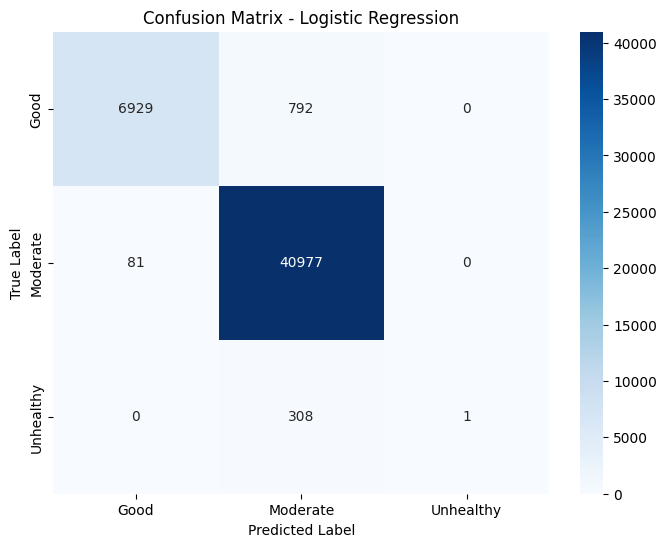



Confusion Matrix for Naive Bayes:


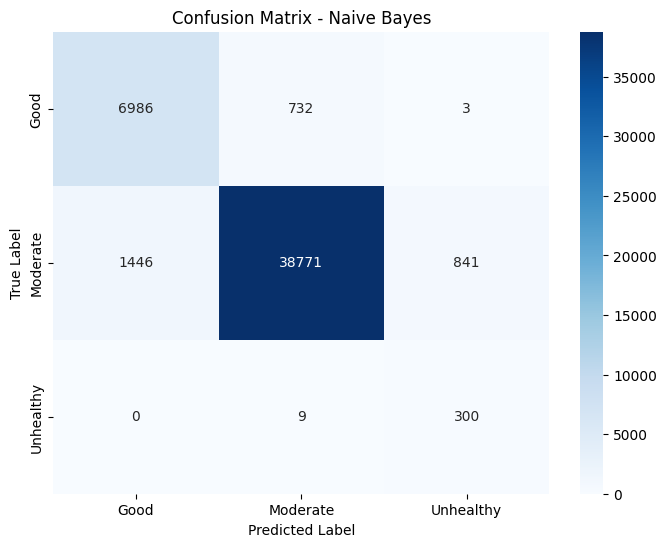



Confusion Matrix for Decision Tree:


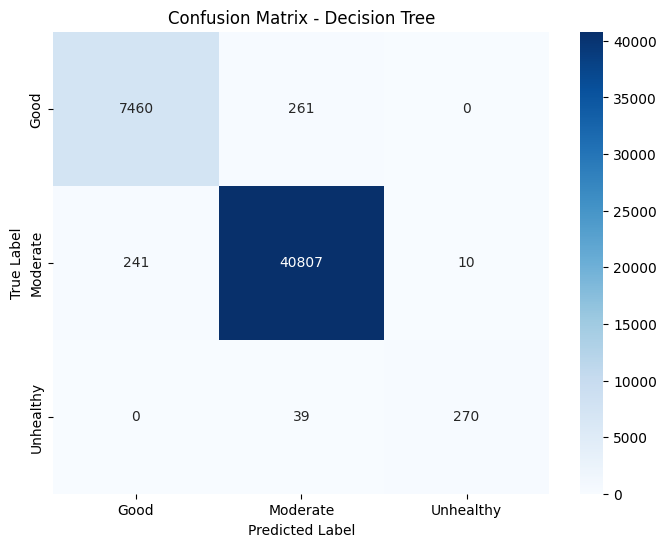



Confusion Matrix for Random Forest:


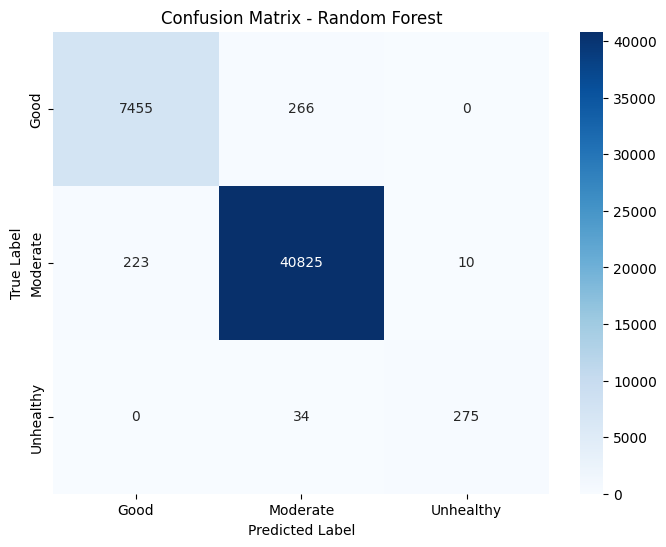



Confusion Matrix for KNN:


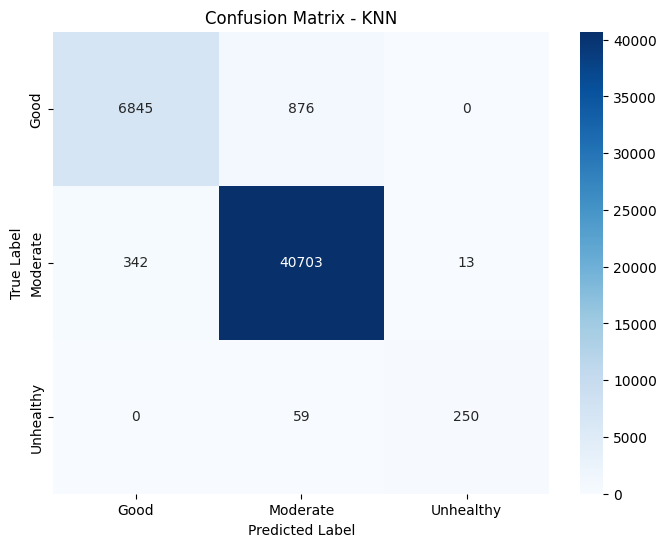

In [20]:
# Print and Save Test Confusion Matrix

for name, results in classification_results.items():
    # Print confusion matrix
    print(f"Confusion Matrix for {name}:")
    cm = results['confusion_matrix']
    
    # Plot the confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',
                xticklabels=['Good', 'Moderate', 'Unhealthy'],
                yticklabels=['Good', 'Moderate', 'Unhealthy'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {name}')
    plt.savefig(f"{report_folder_path}/{name}-confusion-matrix.png")
    plt.show()

    print("\n")  # Add a newline for better readability

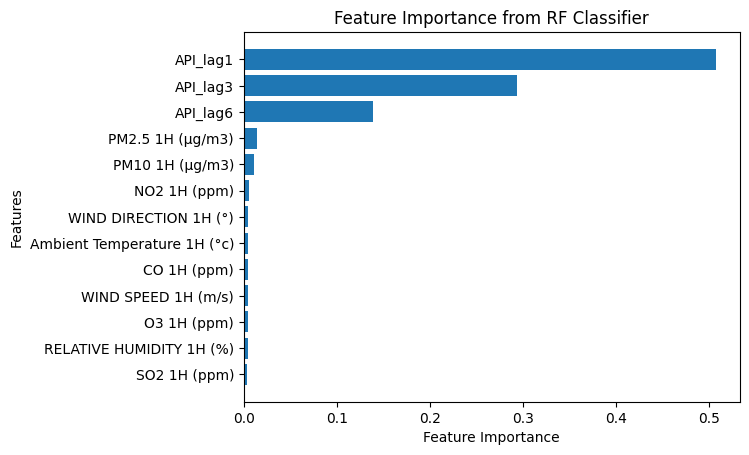

In [7]:
# Load the model
best_model = joblib.load('../models/classification/with_lag_values/classification_rf_model.pkl')

# Get feature importances
importances = best_model.feature_importances_

# If you have the list of feature names
feature_names = X_train.columns  # or wherever your training data is stored

# Combine into a DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

importance_df.to_csv(f"{report_folder_path}/best-model-feature-importance.csv", index=False)

plt.barh(importance_df['Feature'],importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance from RF Classifier')
plt.savefig(f"{report_folder_path}/best-model-feature-importance.png")
plt.show()